
# Vizualizace fraktálů

## Projekt VVP

### Autor
**Vsevolod Kucheriavyi** (KUC0389)

---

## Cíl projektu

Tento projekt se zaměřuje na vizualizaci fraktálů. Cílem je implementovat algoritmy pro generování Mandelbrotovy a Juliovy množiny pro funkci

$$
f(z) = z^2 + c, \quad c \in \mathbb{C}
$$

a vytvořit vizualizace pomocí knihoven **NumPy**, **Numba** a **Matplotlib**.

Projekt umožňuje:

- zobrazit Mandelbrotovu množinu,
- zobrazit Juliovu množinu,
- měnit maximální počet iterací,
- měnit parametr $c$ u Juliovy množiny,
- měnit barevné schéma,
- zobrazit různé oblasti fraktálu, což odpovídá přiblížení nebo oddálení.



# 1. Import knihoven


In [1]:

import numpy as np
import matplotlib.pyplot as plt
from numba import njit

plt.rcParams["figure.figsize"] = (9, 7)



# 2. Mandelbrotova množina

Mandelbrotova množina je množina komplexních čísel $c$, pro která posloupnost

$$
z_{n+1} = z_n^2 + c, \quad z_0 = 0
$$

zůstává omezená.

Pro každý bod komplexní roviny počítáme, po kolika iteracích hodnota překročí mez $|z| > 2$.
Tento počet iterací se následně použije pro barevné vykreslení.


In [2]:

@njit
def generate_mandelbrot(width, height, x_min, x_max, y_min, y_max, max_iter):
    result = np.zeros((height, width), dtype=np.float64)

    for py in range(height):
        y = y_min + (py / (height - 1)) * (y_max - y_min)

        for px in range(width):
            x = x_min + (px / (width - 1)) * (x_max - x_min)

            c = complex(x, y)
            z = complex(0.0, 0.0)
            iteration = 0

            while abs(z) <= 2.0 and iteration < max_iter:
                z = z * z + c
                iteration += 1

            result[py, px] = iteration

    return result



# 3. Juliova množina

Juliova množina používá stejný iterační vztah

$$
z_{n+1} = z_n^2 + c
$$

ale parametr $c$ je pevně zvolený a mění se počáteční hodnota $z_0$, která odpovídá bodům komplexní roviny.

Změnou reálné a imaginární části parametru $c$ vznikají různé tvary fraktálu.


In [3]:

@njit
def generate_julia(width, height, x_min, x_max, y_min, y_max, max_iter, c_real, c_imag):
    result = np.zeros((height, width), dtype=np.float64)
    c = complex(c_real, c_imag)

    for py in range(height):
        y = y_min + (py / (height - 1)) * (y_max - y_min)

        for px in range(width):
            x = x_min + (px / (width - 1)) * (x_max - x_min)

            z = complex(x, y)
            iteration = 0

            while abs(z) <= 2.0 and iteration < max_iter:
                z = z * z + c
                iteration += 1

            result[py, px] = iteration

    return result



# 4. Funkce pro vykreslení fraktálu

Funkce `plot_fractal` zobrazuje vypočítaný fraktál pomocí barevné mapy.
Barva každého bodu odpovídá počtu iterací potřebných k překročení prahu divergence.


In [4]:

def plot_fractal(image, x_min, x_max, y_min, y_max, title, cmap="inferno"):
    plt.figure(figsize=(9, 7))
    plt.imshow(
        image,
        extent=[x_min, x_max, y_min, y_max],
        origin="lower",
        cmap=cmap
    )
    plt.title(title)
    plt.xlabel("Reálná osa")
    plt.ylabel("Imaginární osa")
    plt.colorbar(label="Počet iterací do divergence")
    plt.show()



# 5. Základní zobrazení Mandelbrotovy množiny


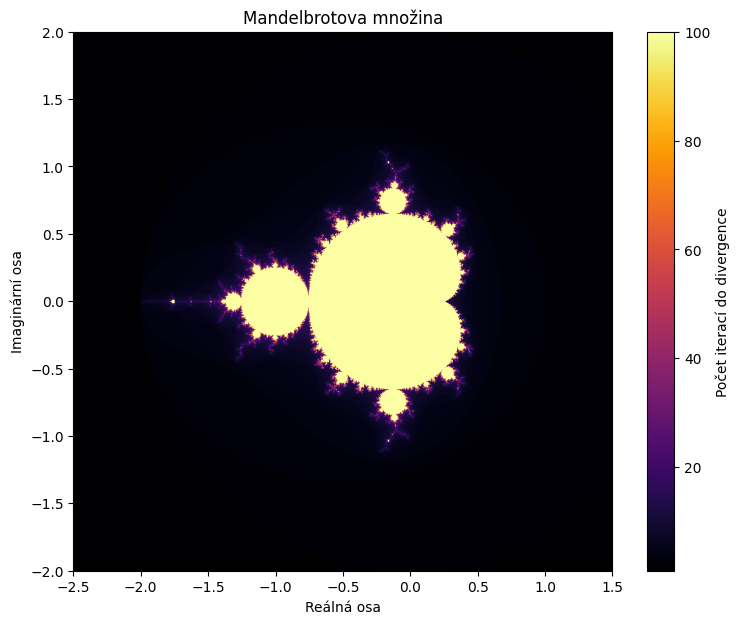

In [5]:

width = 800
height = 800
max_iter = 100

x_min, x_max = -2.5, 1.5
y_min, y_max = -2.0, 2.0

mandelbrot_image = generate_mandelbrot(
    width, height,
    x_min, x_max,
    y_min, y_max,
    max_iter
)

plot_fractal(
    mandelbrot_image,
    x_min, x_max,
    y_min, y_max,
    "Mandelbrotova množina",
    cmap="inferno"
)



# 6. Základní zobrazení Juliovy množiny


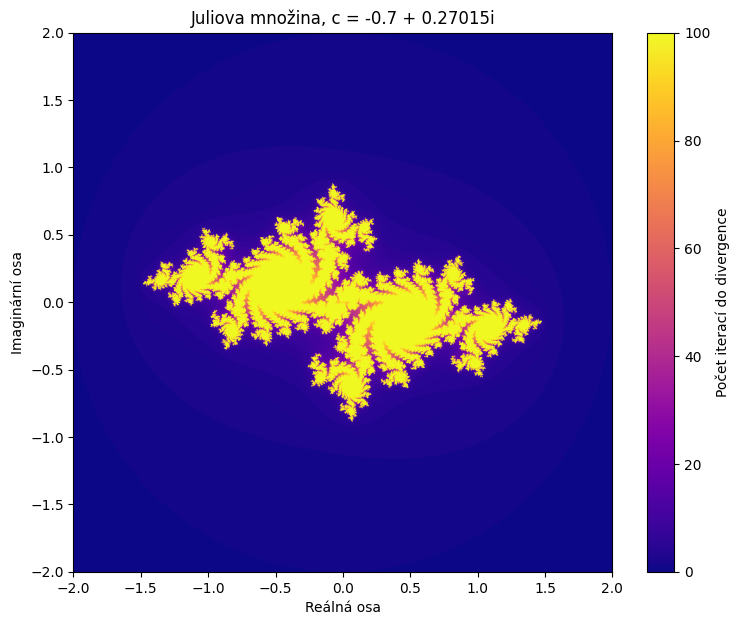

In [6]:

width = 800
height = 800
max_iter = 100

x_min, x_max = -2.0, 2.0
y_min, y_max = -2.0, 2.0

c_real = -0.7
c_imag = 0.27015

julia_image = generate_julia(
    width, height,
    x_min, x_max,
    y_min, y_max,
    max_iter,
    c_real, c_imag
)

plot_fractal(
    julia_image,
    x_min, x_max,
    y_min, y_max,
    f"Juliova množina, c = {c_real} + {c_imag}i",
    cmap="plasma"
)



# 7. Přiblížení Mandelbrotovy množiny

V této části jsou zobrazeny různé oblasti Mandelbrotovy množiny.
Změna hodnot `x_min`, `x_max`, `y_min`, `y_max` odpovídá přiblížení nebo oddálení fraktálu.


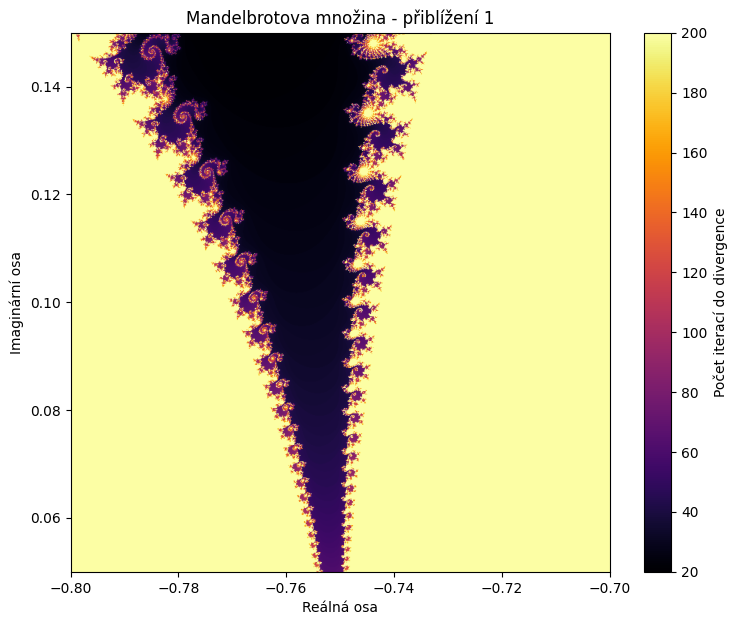

In [7]:

# Přiblížení 1
width = 900
height = 700
max_iter = 200

x_min, x_max = -0.8, -0.7
y_min, y_max = 0.05, 0.15

image_zoom_1 = generate_mandelbrot(
    width, height,
    x_min, x_max,
    y_min, y_max,
    max_iter
)

plot_fractal(
    image_zoom_1,
    x_min, x_max,
    y_min, y_max,
    "Mandelbrotova množina - přiblížení 1",
    cmap="inferno"
)


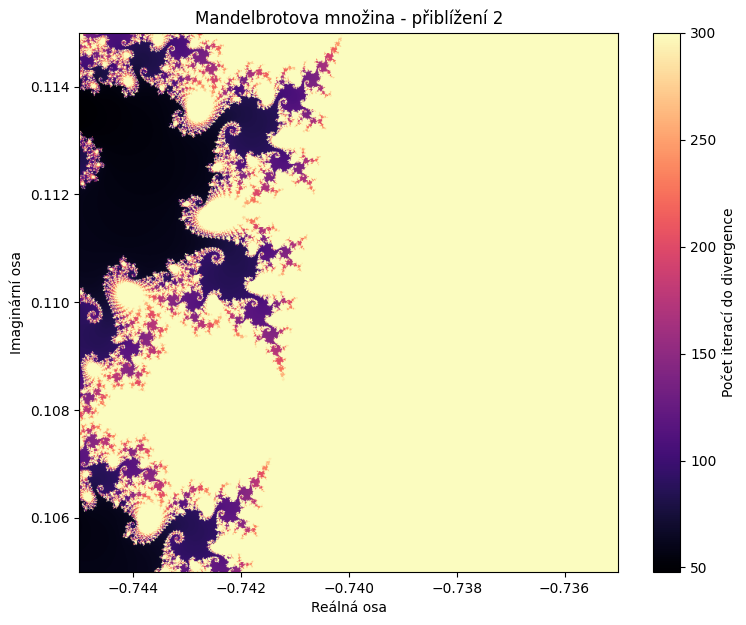

In [8]:

# Přiblížení 2
width = 900
height = 700
max_iter = 300

x_min, x_max = -0.745, -0.735
y_min, y_max = 0.105, 0.115

image_zoom_2 = generate_mandelbrot(
    width, height,
    x_min, x_max,
    y_min, y_max,
    max_iter
)

plot_fractal(
    image_zoom_2,
    x_min, x_max,
    y_min, y_max,
    "Mandelbrotova množina - přiblížení 2",
    cmap="magma"
)


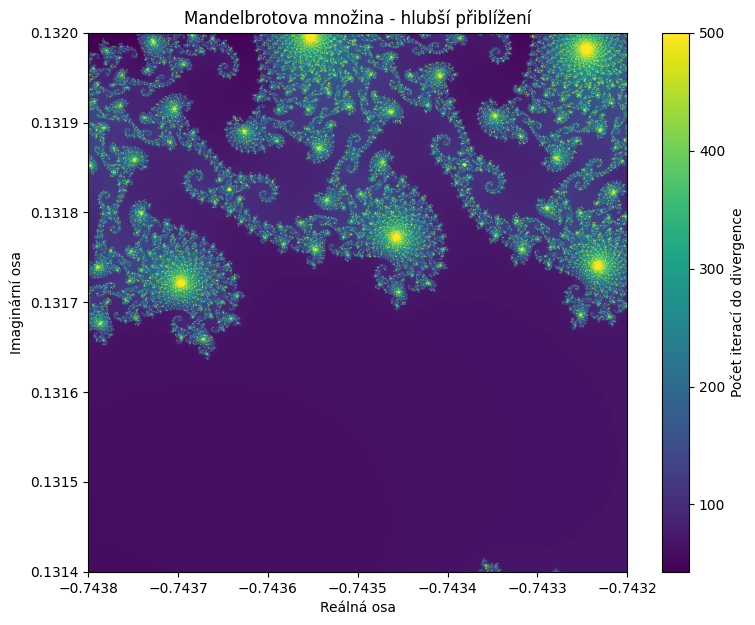

In [9]:

# Přiblížení 3
width = 900
height = 700
max_iter = 500

x_min, x_max = -0.7438, -0.7432
y_min, y_max = 0.1314, 0.1320

image_zoom_3 = generate_mandelbrot(
    width, height,
    x_min, x_max,
    y_min, y_max,
    max_iter
)

plot_fractal(
    image_zoom_3,
    x_min, x_max,
    y_min, y_max,
    "Mandelbrotova množina - hlubší přiblížení",
    cmap="viridis"
)



# 8. Různé parametry Juliovy množiny

Následující příklady ukazují, jak se tvar Juliovy množiny mění podle komplexního parametru $c$.


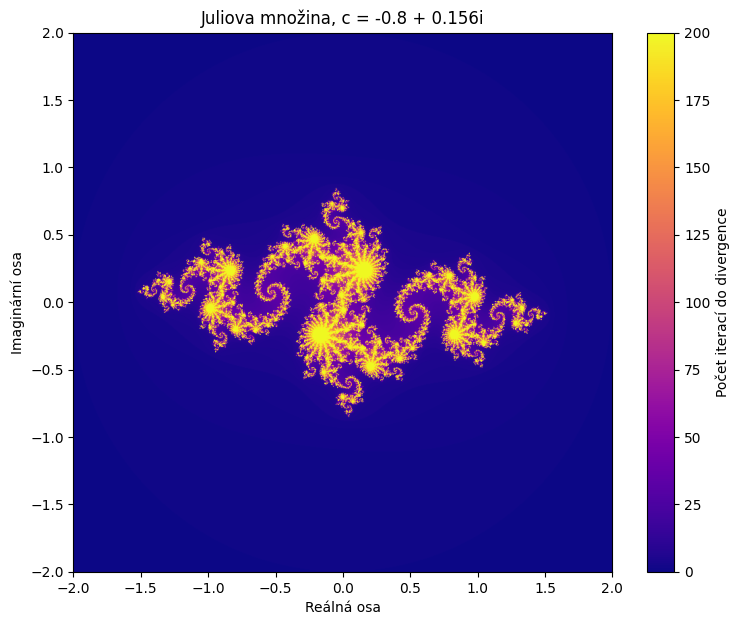

In [10]:

# Julia - varianta 1
width = 800
height = 800
max_iter = 200

x_min, x_max = -2.0, 2.0
y_min, y_max = -2.0, 2.0

c_real = -0.8
c_imag = 0.156

image_julia_1 = generate_julia(
    width, height,
    x_min, x_max,
    y_min, y_max,
    max_iter,
    c_real, c_imag
)

plot_fractal(
    image_julia_1,
    x_min, x_max,
    y_min, y_max,
    f"Juliova množina, c = {c_real} + {c_imag}i",
    cmap="plasma"
)


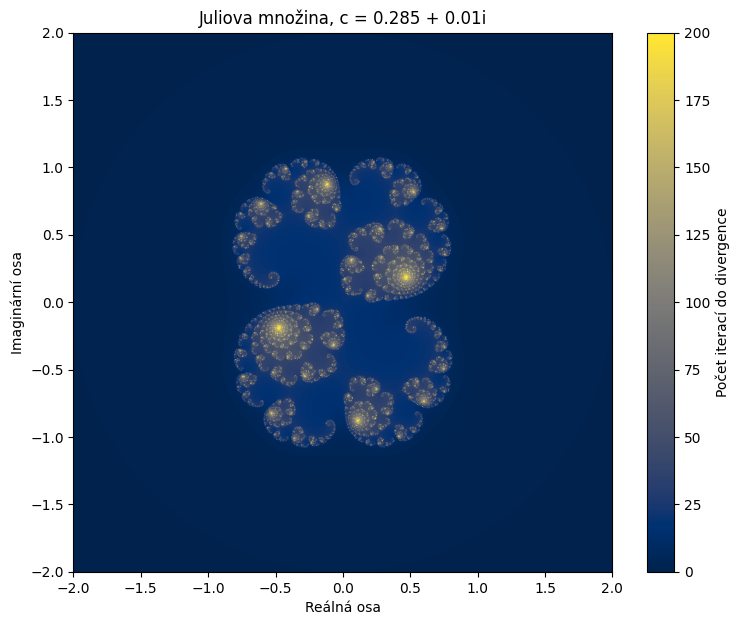

In [11]:

# Julia - varianta 2
width = 800
height = 800
max_iter = 200

x_min, x_max = -2.0, 2.0
y_min, y_max = -2.0, 2.0

c_real = 0.285
c_imag = 0.01

image_julia_2 = generate_julia(
    width, height,
    x_min, x_max,
    y_min, y_max,
    max_iter,
    c_real, c_imag
)

plot_fractal(
    image_julia_2,
    x_min, x_max,
    y_min, y_max,
    f"Juliova množina, c = {c_real} + {c_imag}i",
    cmap="cividis"
)


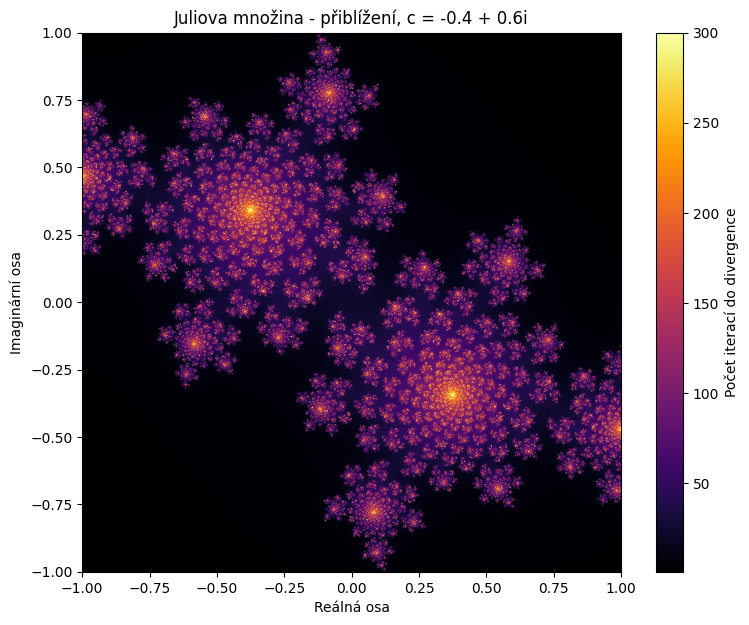

In [12]:

# Julia - varianta 3 s přiblížením
width = 900
height = 700
max_iter = 300

x_min, x_max = -1.0, 1.0
y_min, y_max = -1.0, 1.0

c_real = -0.4
c_imag = 0.6

image_julia_3 = generate_julia(
    width, height,
    x_min, x_max,
    y_min, y_max,
    max_iter,
    c_real, c_imag
)

plot_fractal(
    image_julia_3,
    x_min, x_max,
    y_min, y_max,
    f"Juliova množina - přiblížení, c = {c_real} + {c_imag}i",
    cmap="inferno"
)



# 9. Závěr

V projektu byly implementovány dva známé typy fraktálů: Mandelbrotova a Juliova množina.
Pro výpočty byly použity knihovny **NumPy** a **Numba**, díky kterým lze efektivně počítat velké množství bodů v komplexní rovině.

Vizualizace byla provedena pomocí knihovny **Matplotlib**. Barva každého bodu odpovídá počtu iterací, které byly potřeba k překročení prahu divergence.

Mandelbrotova množina byla zobrazena nejen v základním rozsahu, ale také v několika přiblížených oblastech.
Tím je ukázáno, že i při změně měřítka si fraktál zachovává složitou strukturu.

U Juliovy množiny bylo vyzkoušeno několik různých hodnot komplexního parametru $c$.
Z výsledků je vidět, že změna tohoto parametru výrazně ovlivňuje výsledný tvar fraktálu.
